In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic-Dataset.csv")
print("Dataset Imported")

Dataset Imported


In [27]:
#Explore basic info
print("First Five rows:\n")
print(df.head())
print("\n")
print("Dataset shape: \n")
print(df.shape)
print("\n")
print("Column Info: \n");
print(df.info())
print("\n")
print("Missing Values: \n")
print(df.isnull().sum())
print("\n")
print("Datatypes: \n")
print(df.dtypes);

First Five rows:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

In [28]:
#Categorical and Numeric Columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numeric Columns: \n",numeric_cols)
print("Categorical Columns: \n",categorical_cols)

Numeric Columns: 
 ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Columns: 
 ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [29]:
#Handle Missing Values
#Numeric data -> Median & categorical -> Mode
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop("Cabin",axis=1)
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [30]:
#Covert Categorical features into numerical features using encoding
#LabelEncoding->Sex column as it consists of only binary Male and Female
#OnHOtEncoder -> Embarked as it contains three different class s,c,q
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df = pd.get_dummies(df,columns=["Embarked"],drop_first=True,dtype=int)
print("DONE")

DONE


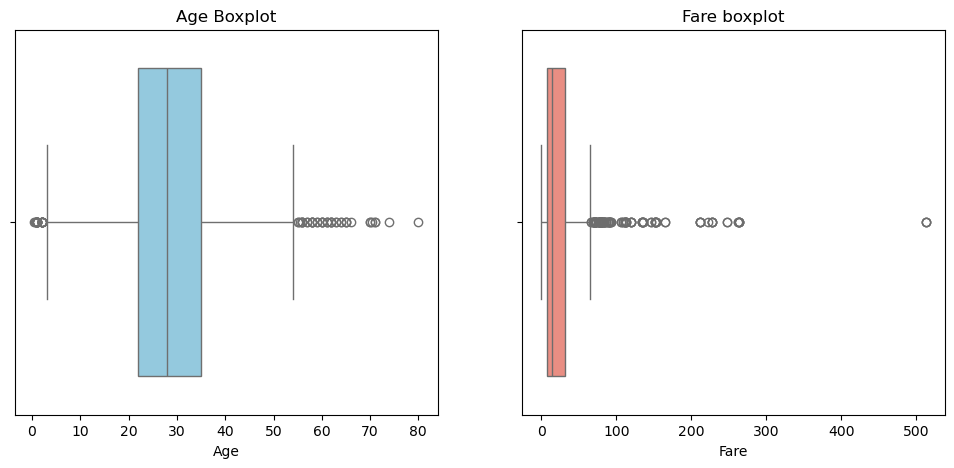

In [31]:
#Visualize outliers and remove them
#InterQuartile range Method
import seaborn as sns
fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.boxplot(ax=axes[0],x=df['Age'],color="skyblue")
axes[0].set_title("Age Boxplot")

sns.boxplot(ax=axes[1],x=df['Fare'],color='salmon')
axes[1].set_title("Fare boxplot")
plt.show()

In [36]:
#Remove outliers
outlier_cols = ["Age","Fare"]
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df = df[(df[col]>=lower) & (df[col]<=upper)]
print(f"Dataset after removing outliers: {df.shape}")    

Dataset after removing outliers: (705, 12)


In [39]:
#Normalize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
nums_cols = ['Age','Fare']
df[nums_cols] = scaler.fit_transform(df[nums_cols])
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    1 -0.636343      1      0   
2                        Heikkinen, Miss. Laina    0 -0.214706      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.733977      1      0   
4                      Allen, Mr. William Henry    1  0.733977      0      0   
5                              Moran, Mr. James    1 -0.003887      0      0   

             Ticket      Fare  Embarked_Q  Embarked_S  
0         A/5 21171 -0.740778           0           1  
2  STON/O2. 3101282 -0.689142           0           1  
3            113803  2.766613           0           1  
4            373450 -0.679580           0           1  
5            330877 -0